In [1]:
# Python Standard Library
import sys
from os import mkdir
from os.path import join
from os.path import isdir
from shutil import rmtree

# Community Modules
from tqdm import tqdm
import numpy as np
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt

# My Modules
sys.path.insert(0, "../code")
import measure_signal as ms
import dataset_utils as du

rng = np.random.default_rng(1415)

2026-03-26 21:51:07.192117: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-26 21:51:07.214795: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-26 21:51:07.221193: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-26 21:51:07.238807: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-26 21:51:09.409611: W tensorflow/compiler/tf2

In [2]:
wvl, df_meta, spectra, spectra_signal, spectra_noise = du.load_dataset()

num_wvl = wvl.size
num_spectra = spectra.shape[0]

In [3]:
num_random_sample = 10
ind_random_sample = rng.choice(df_meta.index, size=num_random_sample, replace=False)

In [4]:
new_SNR_vals = [1, 2, 5, 10, 25, 100]
num_SNR_vals = len(new_SNR_vals)

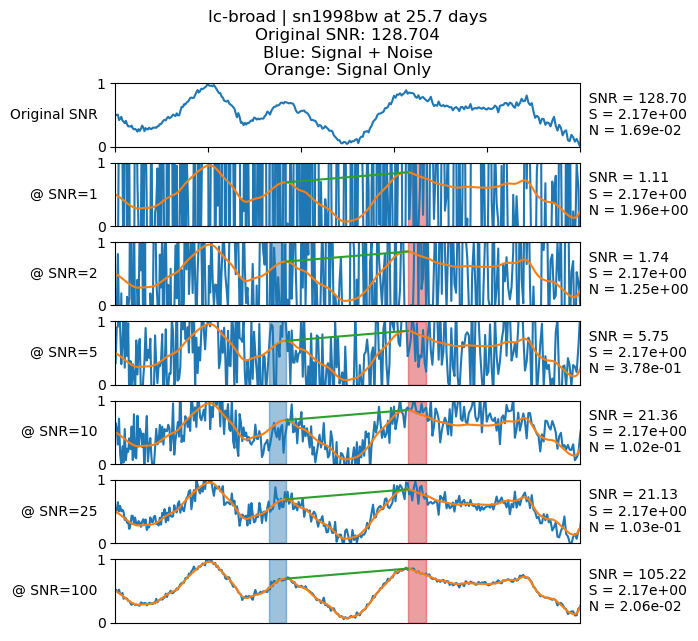

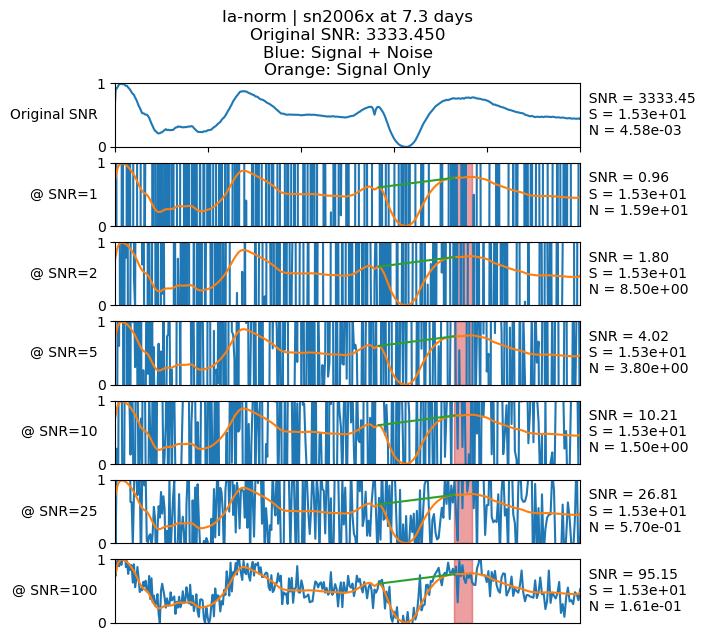

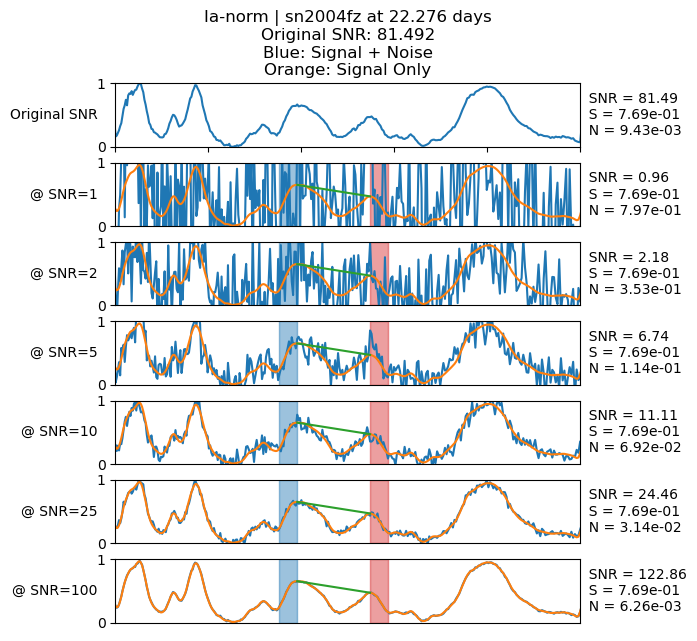

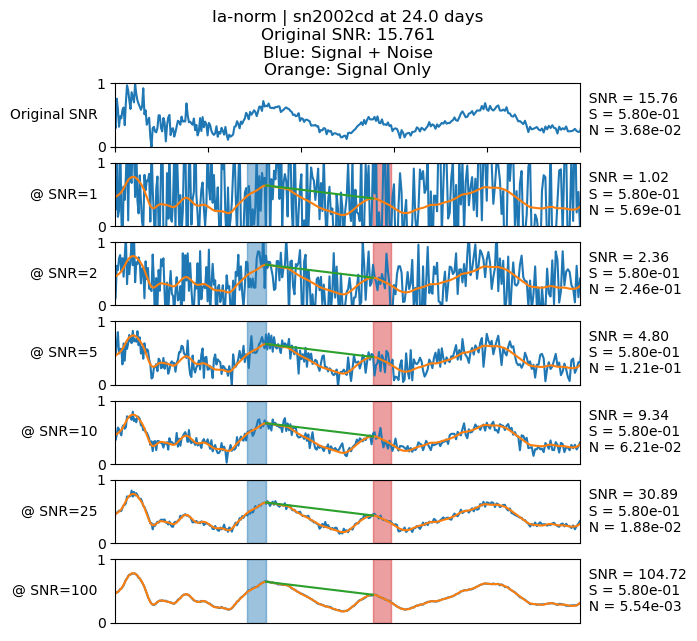

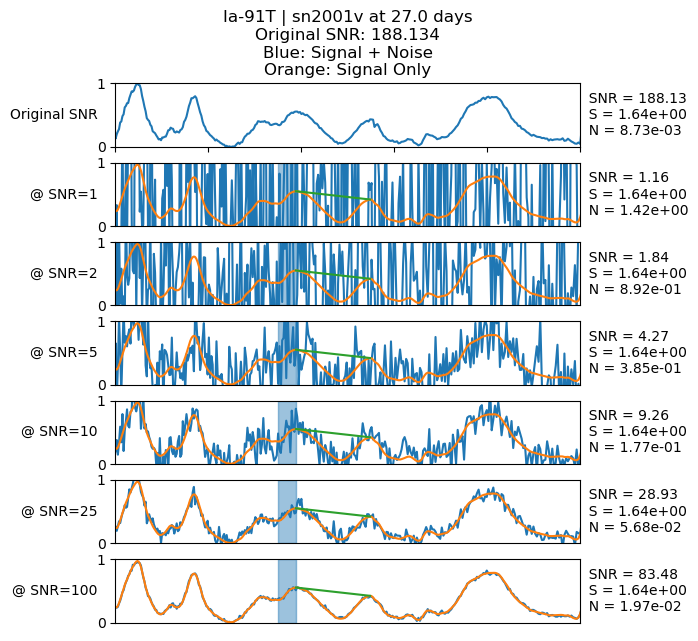

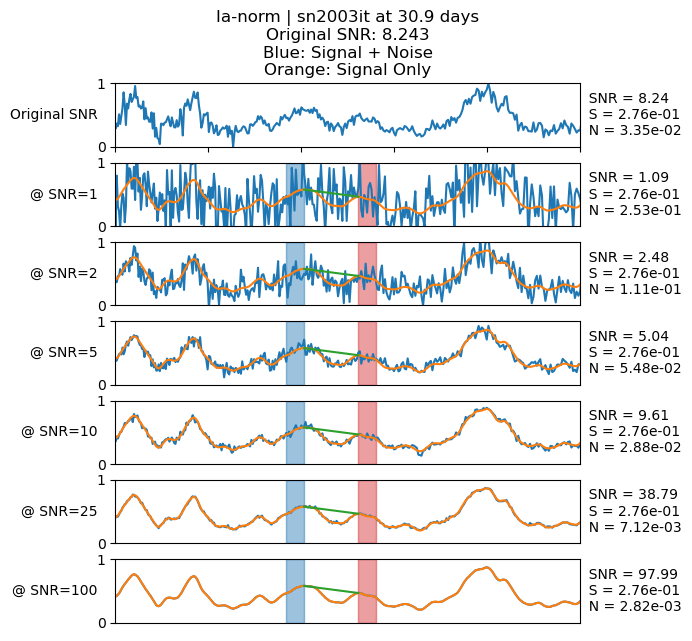

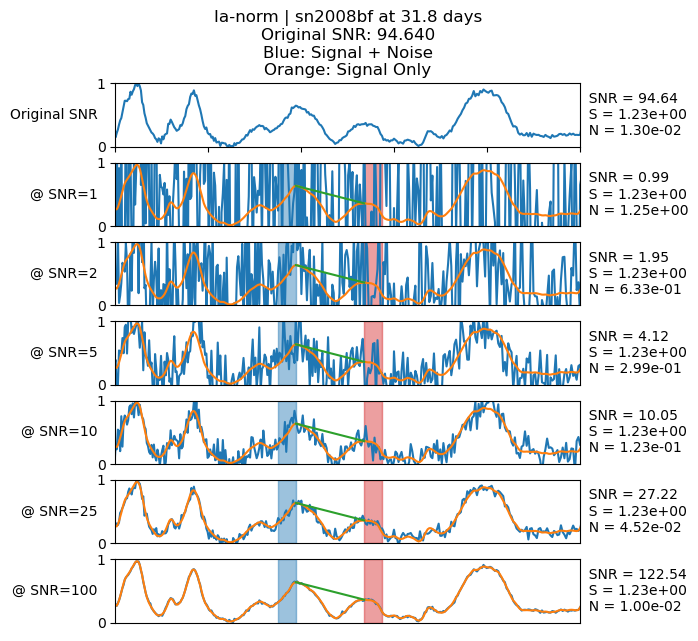

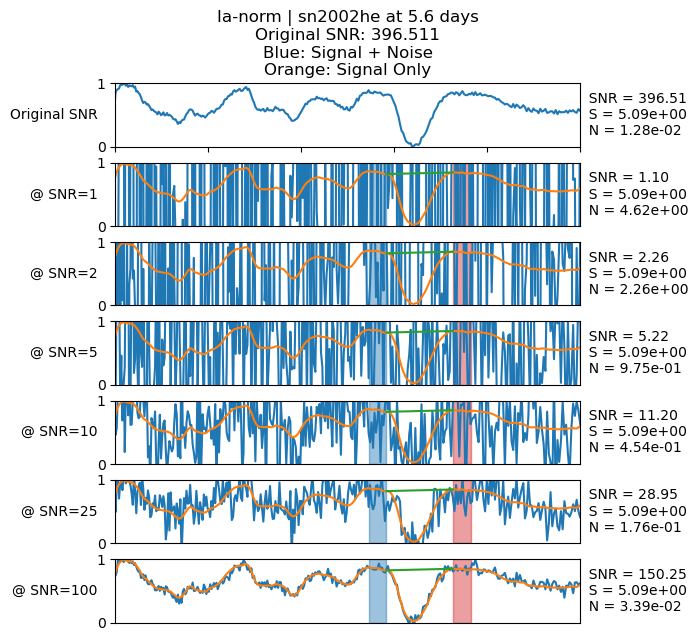

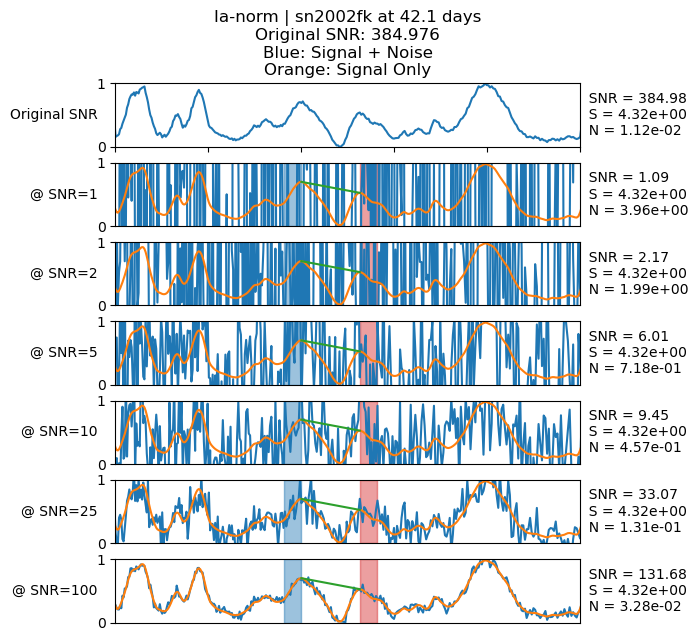

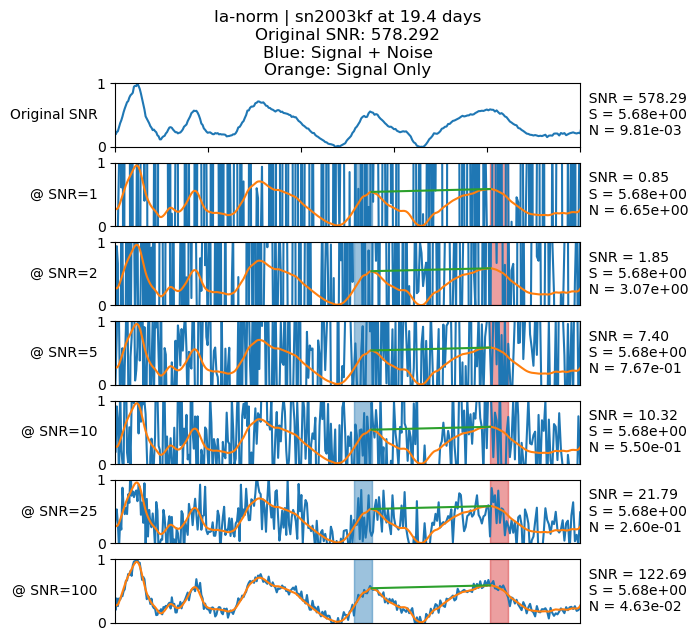

In [5]:
for i, ind in enumerate(ind_random_sample):
    
    fig, axes = plt.subplots(
        nrows=num_SNR_vals+1,
        ncols=1,
        sharex=True,
        sharey=True,
        figsize=(6, num_SNR_vals+1))

    fig.subplots_adjust(hspace=.25)
    title = f'{df_meta.loc[ind, "SN Subtype"]} | '
    title += f'{df_meta.loc[ind, "SN Name"]} at '
    title += f'{df_meta.loc[ind, "Spectrum Phase"]} days'
    title += f'\nOriginal SNR: {df_meta.loc[ind, "SNR"]:.3f}'
    title += f'\nBlue: Signal + Noise'
    title += f'\nOrange: Signal Only'

    specsnr = ms.SpectrumSNR(
        df_meta.loc[ind, "SN Name"],
        df_meta.loc[ind, "SN Subtype"],
        df_meta.loc[ind, "Spectrum Phase"],
        wvl,
        spectra[ind],
    )
    specsnr.execute_algorithm(df_meta.loc[ind])
    ax = axes[0]
    ax.set_title(title)
    ax.plot(wvl, specsnr.spectrum)
    ax.set_xlim((4500, 7000))
    ax.set_ylim((0, 1))

    vertical_midpoint = np.sum(ax.get_ylim()) / 2
    horizontal_text_location = ax.get_xlim()[0]
    ax.text(
        horizontal_text_location, vertical_midpoint,
        f"Original SNR    ",
        ha="right", va="center")
    
    horizontal_text_location = ax.get_xlim()[1]
    ax.text(
        horizontal_text_location, vertical_midpoint,
        f'  SNR = {df_meta.loc[ind, "SNR"]:.2f}\n  S = {df_meta.loc[ind, "S (SNR)"]:.2e}\n  N = {df_meta.loc[ind, "N (SNR)"]:.2e}',
        ha="left", va="center")
    
    for j, new_SNR in enumerate(new_SNR_vals):
        new_N = (df_meta["S (SNR)"] / new_SNR).to_numpy()
        new_N_arr = np.full((num_spectra, num_wvl), new_N[..., np.newaxis])
        new_noise = stats.norm.rvs(loc=0, scale=new_N_arr, random_state=rng)
        new_spectra = spectra_signal + new_noise

        specsnr = ms.SpectrumSNR(
            df_meta.loc[ind, "SN Name"],
            df_meta.loc[ind, "SN Subtype"],
            df_meta.loc[ind, "Spectrum Phase"],
            wvl,
            spectra[ind],
        )
        specsnr.execute_algorithm(df_meta.loc[ind], new_noise=new_noise[ind])

        ax = axes[j+1]

        ax.set_xlim((4500, 7000))
        ax.set_ylim((0, 1))

        ax.get_xaxis().set_visible(False)
        ax.set_yticks([0, 1], [0, 1])
        
        # ax.axis("off")
        ax.plot(wvl, specsnr.signal + specsnr.noise)
        ax.plot(wvl, specsnr.signal)

        vertical_midpoint = np.sum(ax.get_ylim()) / 2
        horizontal_text_location = ax.get_xlim()[0]
        ax.text(
            horizontal_text_location, vertical_midpoint,
            f"@ SNR={new_SNR}    ",
            ha="right", va="center")
        
        horizontal_text_location = ax.get_xlim()[1]
        ax.text(
            horizontal_text_location, vertical_midpoint,
            f"  SNR = {specsnr.SNR:.2f}\n  S = {specsnr.S:.2e}\n  N = {specsnr.N:.2e}",
            ha="left", va="center")

        ax.plot(specsnr.pc_wvl, specsnr.pseudo_cont, c="tab:green")
    
        if specsnr.useBlu:
            ax.fill_between(
                specsnr.wvl[specsnr.blu_inds],
                y1=1,
                y2=0,
                color="tab:blue",
                alpha=0.25)
            ax.fill_between(
                specsnr.wvl[specsnr.blu_inds],
                y1=1,
                y2=0,
                color="tab:blue",
                alpha=0.25)
    
        if specsnr.useRed:
            ax.fill_between(
                specsnr.wvl[specsnr.red_inds],
                y1=1,
                y2=0,
                color="tab:red",
                alpha=0.25)
            ax.fill_between(
                specsnr.wvl[specsnr.red_inds],
                y1=1,
                y2=0,
                color="tab:red",
                alpha=0.25)

    fig.show()
    display(plt.gcf())
    plt.close()

In [6]:
# new_SNR_vals = [1, 2, 5, 10, 25, 100]

# for new_SNR in new_SNR_vals:
#     new_N = (df_meta["S (SNR)"] / new_SNR).to_numpy()
#     new_N_arr = np.full((num_spectra, num_wvl), new_N[..., np.newaxis])
#     new_noise = stats.norm.rvs(loc=0, scale=new_N_arr, random_state=rng)
#     new_spectra = spectra_signal + new_noise

#     fig, axes = plt.subplots(nrows=num_random_sample, ncols=1, figsize=(6, num_random_sample))
#     for i, ind in enumerate(ind_random_sample):
        
#         ax = axes[i]

#         ax.set_xlim((4500, 7000))
#         ax.axis("off")
#         ax.plot(wvl, new_spectra[ind])

#         vertical_midpoint = np.sum(ax.get_ylim()) / 2
#         horizontal_text_location = ax.get_xlim()[0]
#         ax.text(
#             horizontal_text_location, vertical_midpoint,
#             f'{df_meta.loc[ind, "SN Name"]}\n{df_meta.loc[ind, "SN Subtype"]}\n{df_meta.loc[ind, "Spectrum Phase"]} days',
#             ha="right", va="center")
        
#         # horizontal_text_location = ax.get_xlim()[1]
#         # ax.text(
#         #     horizontal_text_location, vertical_midpoint,
#         #     f"SNR = {specsnr.SNR:.2f}\nS = {specsnr.S:.2e}\nN = {specsnr.N:.2e}\n$\sigma = {specsnr.denoising_parameter}$",
#         #     ha="left", va="center")

#     fig.show()
#     display(plt.gcf())
#     plt.close()

